# **Global Freelancers Dataset**

# **Import Library**

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

# **Memuat Dataset**

In [6]:
file = '/content/global_freelancers_raw.csv'
df = pd.read_csv(file)
df

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%
...,...,...,...,...,...,...,...,...,...,...,...,...
995,FL250996,Albert Wilcox,Male,56.0,Turkey,Turkish,DevOps,13.0,100,0.0,no,68%
996,FL250997,Cheryl Norris,f,26.0,Germany,German,Blockchain Development,6.0,USD 40,2.8,N,82
997,FL250998,Kathy Watkins,female,37.0,Japan,Japanese,Data Analysis,15.0,75,NaN,False,94%
998,FL250999,John Obrien,m,46.0,Russia,Russian,Machine Learning,22.0,100,2.8,yes,97


# **Business Understanding**

## **Business Objective**

Di era perkembangan teknologi dan internet yang semakin hari semakin canggih membuat pekerjaan freelancer memiliki banyak peminat. Banyak orang memilih untuk melakukan pekerjaan freelancer karena pekerjaannya yang fleksibel, serta memiliki potensi untuk mendapatkan penghasilan tak terbatas. Tujuan utama dari analisis berdasarkan dataset ini adalah untuk mengetahui bagaimana penyebaran pekerjaan freelancer paling banyak di dunia, skill apa yang paling banyak dimiliki oleh freelancer, bagaimana pengalaman yang lebih tinggi dapat memengaruhi pendapatan freelancer, serta membandingkan pendapatan freelancer dari berbagai negara. Data ini dapat digunakan untuk memahami bagaimana kondisi dan karakteristik freelancer secara global.

## **Assess Situation**

Dataset ini berisi data mentah tentang freelancer fiktif dari berbagai dunia. Data ini memuat informasi seperti identitas freelancer, skill yang dimiliki, asal negara, pengalaman, rating, dan beberapa informasi lainnya yang datanya tidak konsisten, format data yang masih berantakan, dan data palsu yang dibuat dari library palsu menggunakan Python. Dari data ini tidak ada yang menggunakan data asli berdasarkan dunia nyata, namun data ini dapat membantu untuk melihat bagaimana pola dan perbandingan freelancer secara keseluruhan di dunia, di mana informasi ini dapat digunakan untuk memahami kondisi pasar freelancer dan faktor apa yang memengaruhi pendapatan freelancer.

## **Analytic Goals**

Berdasarkan tujuan analisis yang telah ada, adapun tahapan yang lebih spesifik dan terarah agar dapat menghasilkan suatu insight yang relevan dan mendukung pengambilan keputusan untuk mencapai tujuan analisis, antara lain:

1.	Mengidentifikasi persebaran freelancer di berbagai dunia untuk melihat distribusi pekerjaan freelancer, dan negara dengan jumlah freelancer tertinggi di dunia.
2.	Menganalisis tingkat pendapatan freelancer di berbagai negara untuk mengetahui wilayah negara dengan penghasilan tinggi agar dapat melihat apakah terdapat perbedaan kondisi ekonomi freelancer antar negara.
3.	Menganalisis hubungan antara pengalaman kerja dengan tingkat pendapatan freelancer agar mengetahui apakah lama tidaknya pengalaman kerja akan diikuti oleh besar kecilnya pendapatan freelancer.
4.	Mengetahui faktor-faktor yang memengaruhi kondisi dan performa freelancer dalam skala global.

## **Project Plan**

Dalam analisis dataset ini akan dilakukan tahapan, antara lain:
1. Memahami, membersihkan, dan menyiapkan data.
2. Menganalisis dan mengidentifikasi pola atau tren yang ada.
3. Membuat grafik untuk menampilkan hasil dari analisis.
4. Memberikan insight atau kesimpulan berdasarkan data.

# **Data Understanding**

## **Struktur Data**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 1000 Baris dan 12 Kolom.

1. freelancer_ID: Jumlah baris 1000, Tipe data: object, Deskripsi: ID Freelancer
2. name: Jumlah baris 1000, Tipe data: object, Deskripsi: Nama freelancer
3. gender: Jumlah baris: 1000, Tipe data: object, Deskripsi: Jenis kelamin freelancer
4. age: Jumlah baris: 970, Tipe data: float64, Deskripsi: Umur freelancer
5. country: Jumlah baris: 1000, Tipe data: object, Deskripsi: Negara asal freelancer
6. language: Jumlah baris: 1000, Tipe data: object, Deskripsi: Bahasa yang digunakan oleh freelancer
7. primary_skill: Jumlah baris: 1000, Tipe data: object, Deskripsi: Keahlian utama yang dimiliki oleh freelancer
8. years_of_experience: Jumlah baris: 949, Tipe data: float64, Deskripsi: Berapa lama berpengalaman menjadi freelancer
9. hourly_rate (USD): Jumlah baris: 906, Tipe data: object, Deskripsi: Penghasilan per jam menjadi freelancer
10. rating: Jumlah baris: 899, Tipe data: float64, Deskripsi: Penilaian performa freelancer dari klien
11. is_active: Jumlah baris: 911, Tipe data: object, Deskripsi: Status freelancer apakah masih aktif atau sudah tidak aktif
12. client_satisfaction: Jumlah baris: 824, Tipe data: object, Deskripsi: Kepuasan klien terhadap freelancer

## **Statistik Deskriptif**

In [9]:
df.describe(include='all')

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
count,1000,1000,1000,970.000000,1000,1000,1000,949.000000,906,899.000000,911,824
unique,1000,992,10,NaN,21,16,10,NaN,18,NaN,8,81
top,FL251000,Robert Evans,FEMALE,NaN,South Korea,English,DevOps,NaN,40,NaN,1,68%
freq,1,2,115,NaN,68,215,112,NaN,94,NaN,190,23
mean,NaN,NaN,NaN,40.509278,NaN,NaN,NaN,11.340358,NaN,2.512570,NaN,NaN
std,NaN,NaN,NaN,11.942605,NaN,NaN,NaN,9.680610,NaN,1.546599,NaN,NaN
min,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,3.000000,NaN,1.400000,NaN,NaN
50%,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,9.000000,NaN,2.600000,NaN,NaN
75%,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,17.000000,NaN,3.800000,NaN,NaN


1. Count (Kelengkapan Data) Berdasarkan data, total baris adalah 1000. Maka dapat disimpulkan:


*   age memiliki 30 data yang hilang (1000 - 970)


*   years_of_experience memiliki 51 data yang hilang (1000 - 949)


*   hourly_rate (USD) memiliki 94 data yang hilang (1000 - 906)
*   rating memiliki 101 data yang hilang (1000 - 899)


*   is_active memiliki 89 data yang hilang (1000 - 911)
*   client_satisfaction memiliki 176 data yang hilang (1000 - 824)

Kesimpulannya adalah pada kolom age, years_of_experience, hourly_rate, is_active, dan client_satisfaction memuat missing values, sedangkan kolom yang lain sudah memiliki data yang lengkap.


---


2. Mean vs Median (Distribusi Data)


*   Kolom age
  
           Mean = 40.509278
           Median = 41.0
  Nilai mean dan median hampir sama sehingga tidak ada pergeseran drastis ke arah kiri atau kanan. Artinya data age seimbang menyebabkan distribusinya cukup stabil.
*   Kolom years_of_experience

           Mean = 11.340358
           Median = 9.0
  Nilai mean lebih besar dibanding nilai median, artinya terdapat beberapa freelancer yang berpengalaman tinggi sehingga distribusinya condong ke arah kanan (right skewed).


*   Kolom rating
  
           Mean = 2.512570
           Median = 2.60
  Nilai mean dan median hampir sama sehingga distribusi cukup seimbang.



---


3. Min dan Max (Validasi Logika)


*   Kolom age
          
          Min = 20
          Max = 60
*   Kolom years_of_experience

          Min = 0
          Max = 41


*   Kolom rating

          Min = 0
          Max = 5
Kesimpulan:


*   Nilai age menunjukkan usia freelancer yang masuk akal dengan minimal usia 20 dan maksimal usia 60.
*   Nilai years_of_experience menunjukkan nilai minimal 0 dan maksimal 41 di mana ini berarti terdapat freelancer yang sudah bekerja sejak usia muda.


*   Nilai rating terdapat keanehan karena skala rating biasanya dimulai dari 1 sampai 5, namun terdapat nilai 0 yang bisa jadi antara freelancer belum mendapatkan rating atau data kosong.


---


4. Standar Deviasi (std) - Variabilitas Data


*   Kolom age

         Mean = 40.509278
         std = 11.942605
*  Kolom years_of_experience

        Mean = 11.340358
        std = 9.680610



*  Kolom rating
     
         Mean = 2.512570
         std = 1.546599
Kesimpulan:


*   Pada kolom age variasi umur cukup besar dan beragam.
*   Pada kolom years_of_experience variasi pengalaman cukup besar, bisa dilihat terdapat beberapa frelancer yang baru memulai dan sudah senior.


*   Pada kolom rating variasi rating juga sangat bervariasi, ada yang rating rendah dan ada yang rating tinggi.




























## **Cek Tipe Data**

In [10]:
df.dtypes

,0
freelancer_ID,object
name,object
gender,object
age,float64
country,object
language,object
primary_skill,object
years_of_experience,float64
hourly_rate (USD),object
rating,float64


Pada kolom hourly_rate (USD), is_active, dan client_satisfaction, seharusnya tipe datanya berupa float atau integer. Kolom lainnya sudah benar tipe data berupa object.

## **Cek Incosistent Values**

In [11]:
print(df['freelancer_ID'].unique())

['FL250001' 'FL250002' 'FL250003' 'FL250004' 'FL250005' 'FL250006'
 'FL250007' 'FL250008' 'FL250009' 'FL250010' 'FL250011' 'FL250012'
 'FL250013' 'FL250014' 'FL250015' 'FL250016' 'FL250017' 'FL250018'
 'FL250019' 'FL250020' 'FL250021' 'FL250022' 'FL250023' 'FL250024'
 'FL250025' 'FL250026' 'FL250027' 'FL250028' 'FL250029' 'FL250030'
 'FL250031' 'FL250032' 'FL250033' 'FL250034' 'FL250035' 'FL250036'
 'FL250037' 'FL250038' 'FL250039' 'FL250040' 'FL250041' 'FL250042'
 'FL250043' 'FL250044' 'FL250045' 'FL250046' 'FL250047' 'FL250048'
 'FL250049' 'FL250050' 'FL250051' 'FL250052' 'FL250053' 'FL250054'
 'FL250055' 'FL250056' 'FL250057' 'FL250058' 'FL250059' 'FL250060'
 'FL250061' 'FL250062' 'FL250063' 'FL250064' 'FL250065' 'FL250066'
 'FL250067' 'FL250068' 'FL250069' 'FL250070' 'FL250071' 'FL250072'
 'FL250073' 'FL250074' 'FL250075' 'FL250076' 'FL250077' 'FL250078'
 'FL250079' 'FL250080' 'FL250081' 'FL250082' 'FL250083' 'FL250084'
 'FL250085' 'FL250086' 'FL250087' 'FL250088' 'FL250089' 'FL250

Pada kolom tersebut data sudah konsisten.

In [12]:
print(df['name'].unique())

['Ms. Nicole Kidd' 'Vanessa Garcia' 'Juan Nelson' 'Amanda Spencer'
 'Lynn Curtis DDS' 'Lisa Johnson' 'Eric Myers' 'Ricky Graham'
 'Sean Martin' 'Matthew Lloyd' 'Gavin Randall' 'Michelle Curtis'
 'Alice Schneider' 'Phillip Shelton' 'Edward Ferguson' 'Wyatt Stout'
 'Laura Johnson' 'Scott Burns' 'Tyler Aguirre' 'Matthew Lawson'
 'James Cherry' 'Samuel Sanford' 'Cesar Greene' 'Melanie Carter'
 'Jennifer Martin' 'Anna Mccann' 'Marissa Bass' 'Alexis Day' 'Megan Jones'
 'Lori Smith' 'Eric Carpenter' 'Timothy Daniels' 'Robert Nelson'
 'Michael Anderson' 'Jessica Snyder' 'Emily Daniels' 'Jamie Ramirez'
 'Amy Harrison' 'Melinda White' 'James Hernandez' 'Angelica Rogers'
 'Savannah Williams' 'Kaitlyn Schmidt' 'Jason Singh' 'Michelle Ramirez'
 'James Brown' 'Mrs. Samantha Simmons' 'Chase Mason' 'Dominique Ward'
 'Lance Griffin' 'Julie Burgess' 'Don Scott' 'Kyle Atkinson' 'Jimmy Hogan'
 'Jennifer Mcintyre' 'Larry Simpson' 'Laura Price' 'Mark Wright'
 'Samantha Mcdaniel' 'Barbara Foster' 'Courtney T

Pada kolom tersebut data sudah konsisten.

In [13]:
print(df['gender'].unique())

['f' 'FEMALE' 'male' 'F' 'female' 'm' 'MALE' 'Female' 'M' 'Male']


Pada kolom tersebut dapat dilihat bahwa data masih tidak konsisten terhadap penulisan jenis kelamin, seperti f, FEMALE, F, dan female. Di mana semua kata tersebut memiliki arti yang sama yaitu perempuan. Maka diperlukan penanganan berupa menyamakan semua kata menjadi Female. Begitu pun dengan kata Male.

In [14]:
print(df['country'].unique())

['Italy' 'Australia' 'Germany' 'Netherlands' 'Indonesia' 'United States'
 'Turkey' 'United Kingdom' 'Argentina' 'Japan' 'India' 'Brazil'
 'South Korea' 'Russia' 'Canada' 'France' 'Egypt' 'South Africa' 'China'
 'Mexico' 'Spain']


Pada kolom tersebut data sudah konsisten.

In [15]:
print(df['language'].unique())

['Italian' 'English' 'German' 'Dutch' 'Indonesian' 'Turkish' 'Spanish'
 'Japanese' 'Hindi' 'Portuguese' 'Korean' 'Russian' 'French' 'Arabic'
 'Afrikaans' 'Mandarin']


Pada kolom tersebut data sudah konsisten.

In [16]:
print(df['primary_skill'].unique())

['Blockchain Development' 'Mobile Apps' 'Graphic Design' 'Web Development'
 'AI' 'Data Analysis' 'UI/UX Design' 'Cybersecurity' 'DevOps'
 'Machine Learning']


Pada kolom tersebut data sudah konsisten.

In [17]:
print(df['hourly_rate (USD)'].unique())

['100' 'USD 100' '50' '$40' '30' '$30' 'USD 75' 'USD 40' nan '$50' '40'
 '75' 'USD 50' 'USD 30' '$20' '20' '$75' '$100' 'USD 20']


Pada kolom tersebut dapat dilihat bahwa format data masih tidak konsisten, ada yang memakai simbol dolar dan ada yang tidak. Maka diperlukan penanganan berupa menuliskan semua data menggunakan simbol dolar atau menuliskan USD pada awal angka.

In [18]:
print(df['is_active'].unique())

['0' '1' 'N' 'False' 'True' 'yes' 'Y' nan 'no']


Pada kolom tersebut dapat dilihat bahwa masih terdapat data yang tidak konsisten, seperti 0, N, False, nan, dan no. Di mana semua kata tersebut memeiliki arti yang sama. Maka diperlukan penanganan berupa menyamakan semua format penulisan.

In [19]:
print(df['client_satisfaction'].unique())

[nan '84%' '71%' '90%' '83%' '94%' '76%' '77%' '86%' '93%' '70%' '69%'
 '60%' '87%' '75%' '68%' '65%' '100%' '92' '89%' '62%' '82' '81%' '63%'
 '67%' '80%' '74%' '85%' '79%' '72%' '64' '88' '96%' '96' '81' '61%' '97%'
 '64%' '73%' '88%' '72' '92%' '82%' '93' '83' '78' '95%' '80' '87' '66%'
 '78%' '68' '91%' '97' '60' '70' '99%' '76' '86' '95' '74' '100' '73' '67'
 '77' '98%' '71' '85' '91' '94' '84' '90' '62' '65' '75' '63' '61' '66'
 '99' '79' '69' '89']


Pada kolom tersebut dapat dilihat masih terdapat beberapa data yang tidak konsisten, seperti ada yang memakai tanda persen dan yang tidak. Maka diperlukan penanganan berupa menyamakan semua format penulisan dengan memakai tanda persen.

## **Cek Missing Values**

In [20]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
freelancer_ID,0.0
name,0.0
gender,0.0
age,3.0
country,0.0
language,0.0
primary_skill,0.0
years_of_experience,5.1
hourly_rate (USD),9.4
rating,10.1


Pada data di atas dapat dilihat pada kolom age, years_of_experience, hourly_rate (USD), rating, is_active, dan client_satisfaction memiliki missing value dengan nilai terbesar 17% (client_satisfaction), dan terkecil 3% (age). Maka diperlukan penanganan atau menghapus data agar data tetap akurat.

## **Cek Duplicated Values**

In [21]:
df[df.duplicated()]

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction


Pada kolom tersebut dapat dilihat bahwa tidak ada data yang terduplikat, sehingga tidak perlu penanganan.

## **Cek Outliers**

In [22]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
age,0.0
years_of_experience,0.9
rating,0.0


Pada data di atas dapat dilihat bahwa pada kolom age dan rating memiliki nilai 0,0%, artinya seluruh data stabil dan tergolong baik karena tidak ada data anomali. Sedangkan pada kolom years_of_experience terdapat nilai 0,9%, di mana ini menunjukkan adanya outliers. Persentase ini sangat kecil sehingga tidak memengaruhi terhadap keseluruhan analisis data, karena jumlahnya yang masih kurang dari 1%.

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

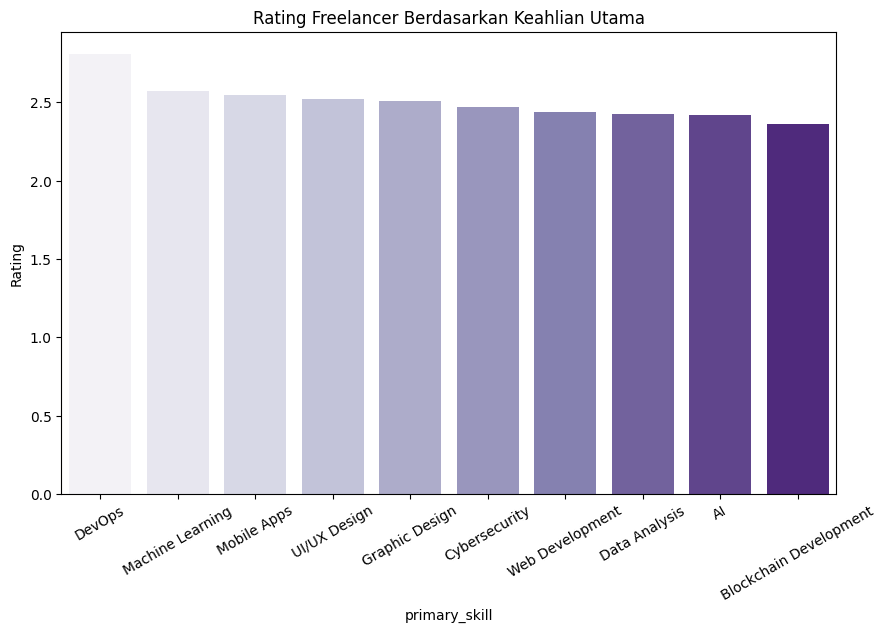

In [23]:
penghasilan_freelancer = df.groupby('primary_skill')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penghasilan_freelancer.index, y=penghasilan_freelancer.values, palette='Purples', hue=penghasilan_freelancer.index, legend=False)
plt.title('Rating Freelancer Berdasarkan Keahlian Utama')
plt.xlabel('primary_skill')
plt.ylabel('Rating')
plt.xticks(rotation=30)
plt.show()

Berdasarkan visual di atas, dapat dilihat bahwa terdapat perbedaan tingkat kepuasan klien pada setiap bidang keahlian. Skill dengan rating tertinggi ada pada DevOps dengan skala nilai sekitar 4, sedangkan skill dengan rating terendah ada pada Blockchain Development dengan skala nilai sekitar 2. Secara keseluruhan tingkat kepuasan klien tidak jauh berbeda.

## **Composition/Komposisi**

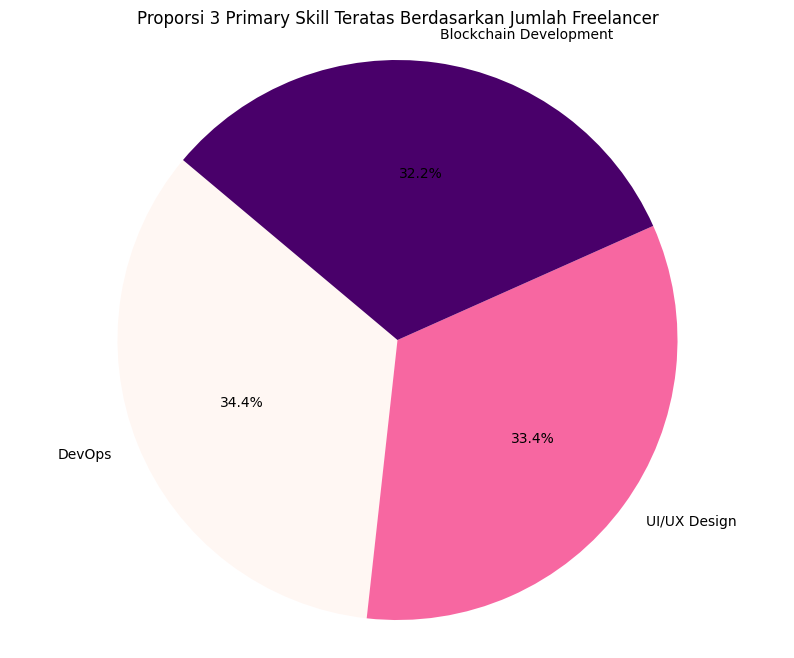

In [24]:
skill_count = df['primary_skill'].value_counts().sort_values(ascending=False)
skill_top3 = skill_count.head(3)

colors = plt.cm.RdPu(np.linspace(0, 1, len(skill_top3)))

plt.figure(figsize=(10, 8))
skill_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Proporsi 3 Primary Skill Teratas Berdasarkan Jumlah Freelancer')
plt.ylabel('')
plt.axis('equal')
plt.show()

Berdasarkan visual di atas, dapat dilihat bahwa ketiga bidang tersebut relatif seimbang. Yaitu DevOps dengan nilai persentase sebesar 34,4%, UI/UX Design dengan nilai persentase sebesar 33,4%, dan Blockchain Development dengan nilai persentase sebesar 32,2. Selisih antar bidang bisa dikatakan tidak ada yang mendominasi secara signifikan.

## **Distribution/Distribusi**

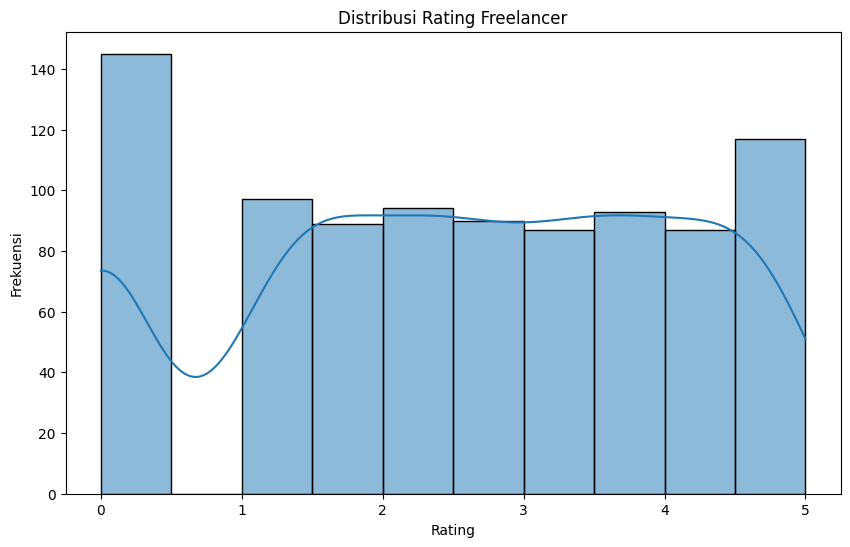

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title('Distribusi Rating Freelancer')
plt.xlabel('Rating')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan visual di atas, dapat dilihat bahwa skala rating ada pada 0 sampai 5. Rating cenderung lebih banyak diskala 2 sampai 5 yang menunjukkan bahwa secara umum freelancer mendapat penilaian yang cukup baik dari klien. Namun, terdapat nilai 0 yang kemungkinan menunjukkan freelancer tidak mendapat penilaian atau performa yang kurang.

## **Relationship/Hubungan**

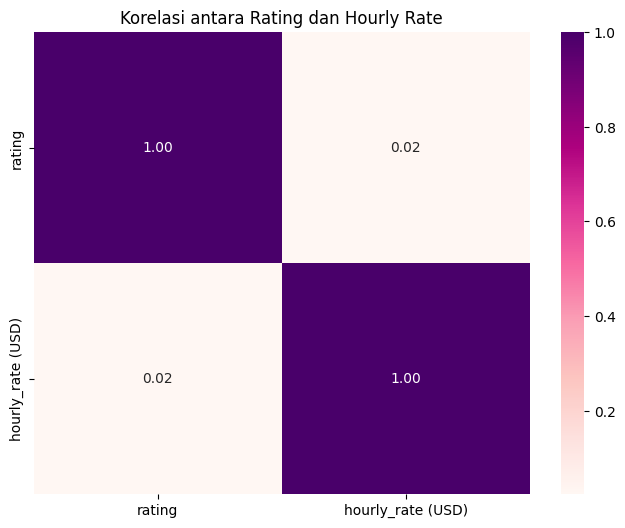

In [26]:
df_cleaned = df.copy()
df_cleaned['hourly_rate (USD)'] = df_cleaned['hourly_rate (USD)'].astype(str).str.replace('USD ', '').str.replace('$', '', regex=False).astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(
    data=df_cleaned[['rating', 'hourly_rate (USD)']].corr(),
    annot=True,
    cmap='RdPu',
    fmt='.2f'
)
plt.title('Korelasi antara Rating dan Hourly Rate')
plt.show()

Berdasarkan visual di atas, dapat dilihat bahwa korelasi antara rating dengan hourly rate memiliki hubungan yang tidak ada. Artinya freelancer dengan rating tinggi tidak selalu memiliki penghasilan yang tinggi, begitu pun dengan freelancer dengan rating rendah tidak selalu memiliki penghasilan yang rendah juga. Bisa dikatakan bahwa dalam dataset ini harga jasa tidak dipengaruhi oleh tingkat kepuasan atau penilaian dari klien.